In [1]:
import pandas as pd
import requests


# def load_data_gov_sg_dataset(dataset_id, page_size=10000):
#     url = "https://data.gov.sg/api/action/datastore_search?resource_id=" + dataset_id
#     records = []
#     offset = 0

#     while True:
#         response = requests.get(
#             url,
#             params={"limit": page_size, "offset": offset},
#             timeout=120,
#         )
#         response.raise_for_status()
#         result = response.json()["result"]
#         records.extend(result["records"])

#         if len(records) >= int(result["total"]):
#             break

#         offset += page_size

#     dataframe = pd.DataFrame(records)
#     dataframe["_id"] = pd.to_numeric(dataframe["_id"])
#     return dataframe.sort_values("_id").drop(columns="_id").reset_index(drop=True)


# cea_dataset_id = "d_ee7e46d3c57f7865790704632b0aef71"
# cea_transactions_df = load_data_gov_sg_dataset(cea_dataset_id)
# resale_dataset_id = "d_8b84c4ee58e3cfc0ece0d773c8ca6abc"
# resale_prices_df = load_data_gov_sg_dataset(resale_dataset_id)


import pandas as pd
# Load the HDB resale price CSV into a DataFrame.
resale_prices_df = pd.read_csv(
    "Resale flat prices based on registration date from Jan-2017 onwards.csv"
)
# Load the CEA transaction CSV into a DataFrame.
cea_transactions_df = pd.read_csv(
    "CEASalespersonsPropertyTransactionRecordsresidential.csv"
)
print(f"resale_prices_df: {resale_prices_df.shape[0]:,} rows × {resale_prices_df.shape[1]} columns")
print(f"cea_transactions_df: {cea_transactions_df.shape[0]:,} rows × {cea_transactions_df.shape[1]} columns")
display(resale_prices_df.head())
display(cea_transactions_df.head())
resale_prices_df["floor_area_sqm"] = pd.to_numeric(resale_prices_df["floor_area_sqm"])
resale_prices_df["lease_commence_date"] = pd.to_numeric(resale_prices_df["lease_commence_date"])
resale_prices_df["resale_price"] = pd.to_numeric(resale_prices_df["resale_price"])

resale_prices_df: 239,330 rows × 11 columns
cea_transactions_df: 1,388,678 rows × 9 columns


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0


,salesperson_name,transaction_date,salesperson_reg_num,property_type,transaction_type,represented,town,district,general_location
0,SOH HUI HUA,OCT-2017,P000003I,HDB,RESALE,SELLER,YISHUN,-,-
1,SOH HUI HUA,MAR-2018,P000003I,HDB,RESALE,BUYER,KALLANG/WHAMPOA,-,-
2,SOH HUI HUA,JAN-2017,P000003I,HDB,RESALE,BUYER,YISHUN,-,-
3,SOH HUI HUA,MAY-2018,P000003I,HDB,RESALE,SELLER,CHOA CHU KANG,-,-
4,SOH HUI HUA,NOV-2017,P000003I,HDB,RESALE,SELLER,CHOA CHU KANG,-,-


In [2]:
# LIMITATION: 
# The available datasets do not contain a field showing whether an HDB resale transaction was completed through the HDB Resale Portal.
# The CEA dataset records salesperson-side transaction activity, but does not provide a unique property-sale identifier that can reliably match buyer-side and seller-side records to one HDB resale transaction.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Data cleaning rationale
# - salesperson_name is removed because registration number can identify salesperson.
# - district and general_location are removed due to the lack of usability and null values
# - Keep only Jan-2017 to Dec-2020 so the analysis has one pre-launch year and three post-launch years.
# - A row is interpreted as one salesperson-side transaction record, not necessarily one
#   unique property sale (a sale may have both a buyer's and seller's agent).

salesperson_eda = cea_transactions_df.copy()
# Parse the transaction month text into a datetime column for time-based filtering.
salesperson_eda["transaction_month"] = pd.to_datetime(
    salesperson_eda["transaction_date"], format="%b-%Y", errors="coerce"
)

salesperson_eda = (
    # Keep only records between January 2017 and December 2020.
    salesperson_eda.loc[
        salesperson_eda["transaction_month"].between("2017-01-01", "2020-12-31")
    ]
    # Drop columns that are not needed for interpretation.
    .drop(columns=["salesperson_name", "district", "general_location", "transaction_date"])
    .copy()
)

# Data type cleaning for consistent joins and groups.
for col in ["salesperson_reg_num", "property_type", "transaction_type", "represented", "town"]:
    salesperson_eda[col] = salesperson_eda[col].astype("string").str.strip().str.upper()


print(f"Clean salesperson data: {len(salesperson_eda):,} rows × {salesperson_eda.shape[1]} columns")
print(f"Period: {salesperson_eda['transaction_month'].min():%b %Y} to {salesperson_eda['transaction_month'].max():%b %Y}")
# Print the number of unique salesperson registration numbers in the cleaned dataset.
print(f"Unique registration numbers: {salesperson_eda['salesperson_reg_num'].nunique():,}")
display(salesperson_eda.head())

Clean salesperson data: 271,283 rows × 6 columns
Period: Jan 2017 to Dec 2020
Unique registration numbers: 20,810


,salesperson_reg_num,property_type,transaction_type,represented,town,transaction_month
0,P000003I,HDB,RESALE,SELLER,YISHUN,2017-10-01
1,P000003I,HDB,RESALE,BUYER,KALLANG/WHAMPOA,2018-03-01
2,P000003I,HDB,RESALE,BUYER,YISHUN,2017-01-01
3,P000003I,HDB,RESALE,SELLER,CHOA CHU KANG,2018-05-01
4,P000003I,HDB,RESALE,SELLER,CHOA CHU KANG,2017-11-01


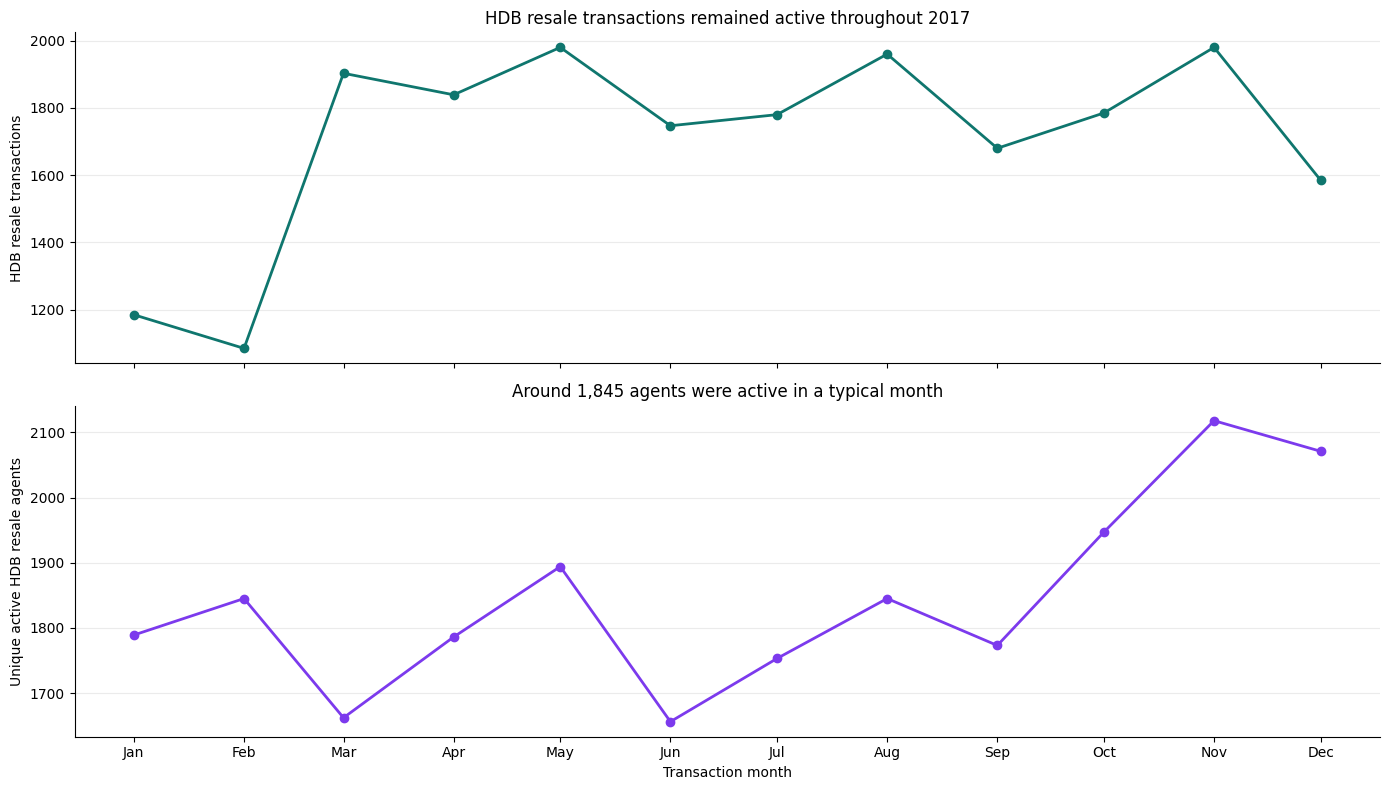

,transaction_month,total_hdb_resale_transactions,active_hdb_resale_agents
0,2017-01-01,1185,1789
1,2017-02-01,1085,1845
2,2017-03-01,1903,1662
3,2017-04-01,1839,1786
4,2017-05-01,1980,1894
5,2017-06-01,1747,1656
6,2017-07-01,1780,1753
7,2017-08-01,1960,1845
8,2017-09-01,1680,1773
9,2017-10-01,1785,1947


,measure,value,interpretation
0,Total HDB resale transactions,20509,Completed HDB resale transactions recorded in ...
1,Average monthly active HDB resale agents,1845,Unique CEA registration numbers with at least ...
2,Active-agent monthly range,"1,656–2,118",Monthly variation in observed active agents


In [4]:
# Create a 2017 monthly HDB resale series from the HDB resale-price dataset.
hdb_market_2017 = resale_prices_df.copy()
# Parse the HDB transaction month for monthly aggregation.
hdb_market_2017["transaction_month"] = pd.to_datetime(hdb_market_2017["month"], format="%Y-%m", errors="coerce")
# Keep only HDB resale transactions recorded during 2017.
hdb_market_2017 = hdb_market_2017.loc[hdb_market_2017["transaction_month"].dt.year.eq(2017)].copy()
# Count total HDB resale transactions in each month.
monthly_hdb_resale_transactions_2017 = (
    hdb_market_2017.groupby("transaction_month", as_index=False)
    .size()
    .rename(columns={"size": "total_hdb_resale_transactions"})
)

# Keep CEA HDB resale agent-side records during 2017.
cea_hdb_resale_2017 = salesperson_eda.loc[
    (salesperson_eda["transaction_month"].dt.year.eq(2017))
    & (salesperson_eda["property_type"].eq("HDB"))
    & (salesperson_eda["transaction_type"].eq("RESALE"))
].copy()
# Count unique active registration numbers in each month.
monthly_active_hdb_agents_2017 = (
    cea_hdb_resale_2017.groupby("transaction_month", as_index=False)
    .agg(active_hdb_resale_agents=("salesperson_reg_num", "nunique"))
)

# Join the two monthly measures by calendar month for side-by-side visual comparison.
hdb_market_role_monthly_2017 = monthly_hdb_resale_transactions_2017.merge(
    monthly_active_hdb_agents_2017,
    on="transaction_month",
    how="left",
    validate="one_to_one"
)
# Create a two-panel figure because transactions and active agents have different units.
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
# Plot monthly total HDB resale transactions in the upper panel.
axes[0].plot(
    hdb_market_role_monthly_2017["transaction_month"],
    hdb_market_role_monthly_2017["total_hdb_resale_transactions"],
    color="#0f766e", marker="o", linewidth=2
)
# Label the transaction panel for a public reader.
axes[0].set(title="HDB resale transactions remained active throughout 2017", ylabel="HDB resale transactions")
# Add a light comparison grid to the transaction panel.
axes[0].grid(axis="y", alpha=0.25)
# Remove the top and right borders for a cleaner visual style.
axes[0].spines[["top", "right"]].set_visible(False)

# Plot unique active HDB resale agents in the lower panel.
axes[1].plot(
    hdb_market_role_monthly_2017["transaction_month"],
    hdb_market_role_monthly_2017["active_hdb_resale_agents"],
    color="#7c3aed", marker="o", linewidth=2
)
# Label the active-agent panel and explain its unit.
axes[1].set(title="Around 1,845 agents were active in a typical month", xlabel="Transaction month", ylabel="Unique active HDB resale agents")
# Format the lower-panel dates as month labels.
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
# Render abbreviated month labels for the 2017 timeline.
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
# Add a light comparison grid to the active-agent panel.
axes[1].grid(axis="y", alpha=0.25)
# Remove the top and right borders for a cleaner visual style.
axes[1].spines[["top", "right"]].set_visible(False)
# Adjust spacing so both panels remain easy to read.
plt.tight_layout()
# Render the market-activity and agent-participation figure.
plt.show()

# Build a compact 2017 summary table for use in the data story.
hdb_market_role_summary_2017 = pd.DataFrame({
    "measure": ["Total HDB resale transactions", "Average monthly active HDB resale agents", "Active-agent monthly range"],
    "value": [
        int(hdb_market_role_monthly_2017["total_hdb_resale_transactions"].sum()),
        round(hdb_market_role_monthly_2017["active_hdb_resale_agents"].mean()),
        f"{int(hdb_market_role_monthly_2017['active_hdb_resale_agents'].min()):,}–{int(hdb_market_role_monthly_2017['active_hdb_resale_agents'].max()):,}"
    ],
    "interpretation": [
        "Completed HDB resale transactions recorded in the HDB price dataset",
        "Unique CEA registration numbers with at least one HDB resale record in a month",
        "Monthly variation in observed active agents"
    ]
})
# Display the monthly data for auditability.
display(hdb_market_role_monthly_2017)
# Display the public-facing 2017 summary table.
display(hdb_market_role_summary_2017)

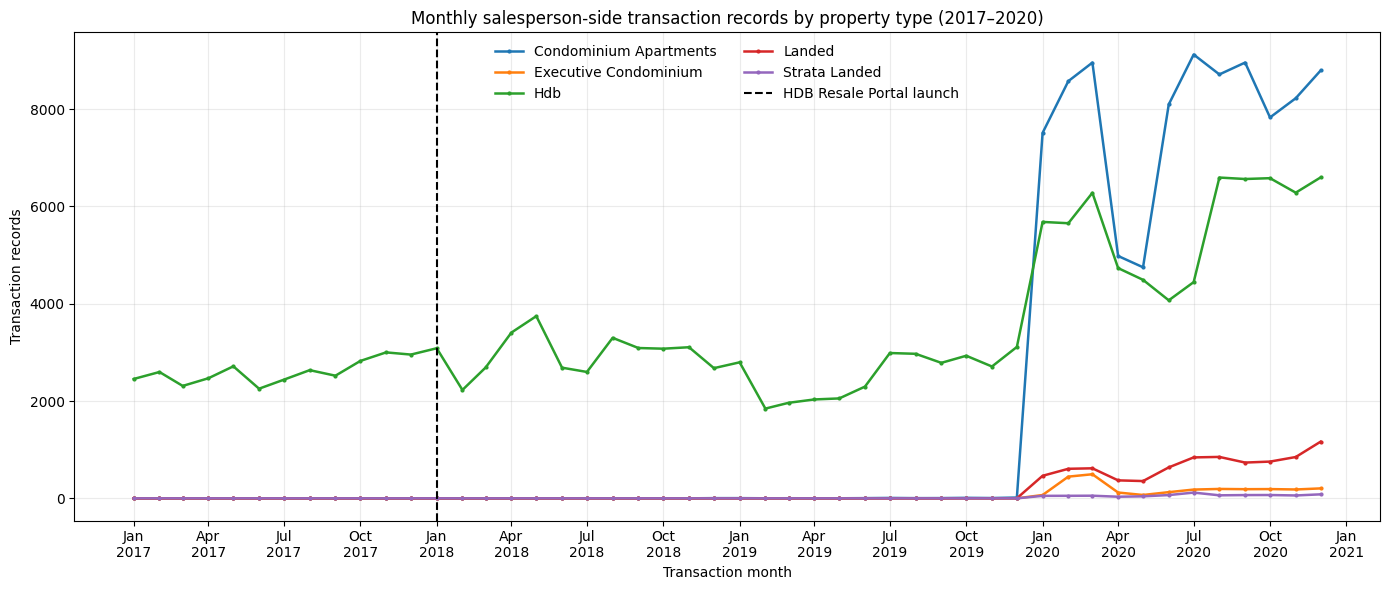

,transaction_month,property_type,transaction_records
0,2017-01-01,HDB,2453
1,2017-02-01,HDB,2596
2,2017-03-01,CONDOMINIUM_APARTMENTS,1
3,2017-03-01,HDB,2310
4,2017-04-01,HDB,2468
5,2017-05-01,HDB,2713
6,2017-06-01,CONDOMINIUM_APARTMENTS,1
7,2017-06-01,HDB,2253
8,2017-07-01,HDB,2439
9,2017-08-01,HDB,2634


property_type,CONDOMINIUM_APARTMENTS,EXECUTIVE_CONDOMINIUM,HDB,LANDED,STRATA_LANDED
year,,,,,
2017,2,0,31162,0,0
2018,8,0,35674,0,0
2019,62,1,30473,3,0
2020,94487,2461,67953,8243,754


Coverage warning: use the HDB resale subset for the Jan-2018 portal impact comparison.


In [5]:
# QUESTION: Per property type, how many salesperson-side transaction records occur each month?
# Counts are only agent-side property sales, and does not include HDB DIY resale transactions

# Count salesperson-side records by month and property type.
monthly_property_transactions = (
    salesperson_eda.groupby(["transaction_month", "property_type"], as_index=False)
    .size()
    .rename(columns={"size": "transaction_records"})
)

# Reshape the monthly counts so each property type becomes its own plot series.
property_pivot = monthly_property_transactions.pivot(
    index="transaction_month", columns="property_type", values="transaction_records"
).fillna(0)

fig, ax = plt.subplots(figsize=(14, 6))
for property_type in property_pivot.columns:
    # Plot the monthly transaction counts for the current property type.
    ax.plot(property_pivot.index, property_pivot[property_type], marker="o", markersize=2,
            linewidth=1.8, label=property_type.replace("_", " ").title())
# Draw a vertical reference line at the HDB Resale Portal launch date.
ax.axvline(pd.Timestamp("2018-01-01"), color="black", linestyle="--", linewidth=1.5,
           label="HDB Resale Portal launch")
ax.set(title="Monthly salesperson-side transaction records by property type (2017–2020)",
       xlabel="Transaction month", ylabel="Transaction records")

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.grid(alpha=0.25)
ax.legend(ncol=2, frameon=False)
plt.tight_layout()
plt.show()

display(monthly_property_transactions.head(10))


# The annual table reveals that 2017–2019 is almost exclusively HDB, while broad private-property
# coverage appears in 2020. Therefore, the impact from private-property transactions is limited.

# Count records within each year-property combination.
property_type_annual_coverage = (
    salesperson_eda.assign(year=salesperson_eda["transaction_month"].dt.year)
    .groupby(["year", "property_type"])
    .size()
    .unstack(fill_value=0)
)

display(property_type_annual_coverage)
print("Coverage warning: use the HDB resale subset for the Jan-2018 portal impact comparison.")

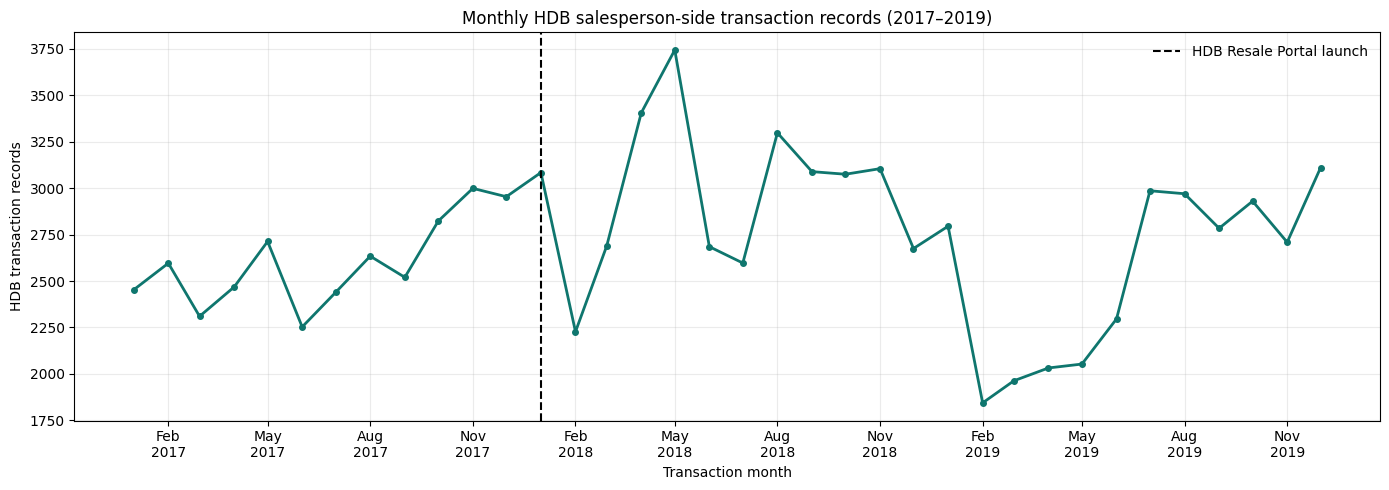

,transaction_month,property_type,transaction_records
0,2017-01-01,HDB,2453
1,2017-02-01,HDB,2596
3,2017-03-01,HDB,2310
4,2017-04-01,HDB,2468
5,2017-05-01,HDB,2713
7,2017-06-01,HDB,2253
8,2017-07-01,HDB,2439
9,2017-08-01,HDB,2634
10,2017-09-01,HDB,2520
11,2017-10-01,HDB,2823


In [6]:
# Because COVID-19 began in December 2019 and the series peaks from January 2020, restrict the HDB chart to January 2017 through December 2019 to avoid mixing pandemic disruption with the portal's impact.
# From above chart and data, non-HDB resale transactions in this dataset only peaked from Jan 2020, hence we can safely focus on HDB sales for analysis
monthly_hdb_transactions = monthly_property_transactions[
    (monthly_property_transactions["property_type"] == "HDB")
    & (monthly_property_transactions["transaction_month"] <= "2019-12-31")
].copy()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(
    monthly_hdb_transactions["transaction_month"],
    monthly_hdb_transactions["transaction_records"],
    color="#0f766e", marker="o", markersize=4, linewidth=2
)
# Mark the January 2018 launch of the HDB Resale Portal.
ax.axvline(
    pd.Timestamp("2018-01-01"),
    color="black", linestyle="--", linewidth=1.5,
    label="HDB Resale Portal launch"
)

#Formatting of graph
ax.set(
    title="Monthly HDB salesperson-side transaction records (2017–2019)",
    xlabel="Transaction month", ylabel="HDB transaction records"
)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.grid(alpha=0.25)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

display(monthly_hdb_transactions)

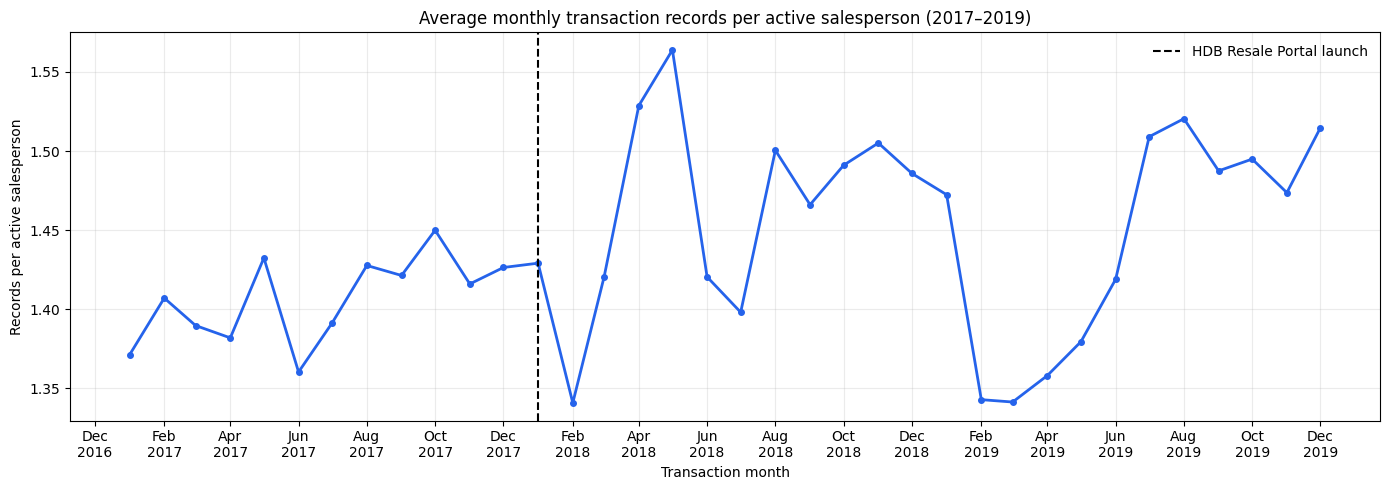

,transaction_month,transaction_records,active_salespersons,transactions_per_active_salesperson
0,2017-01-01,2453,1789,1.371157
1,2017-02-01,2596,1845,1.407046
2,2017-03-01,2311,1663,1.389657
3,2017-04-01,2468,1786,1.381859
4,2017-05-01,2713,1894,1.432418
5,2017-06-01,2254,1657,1.360290
6,2017-07-01,2439,1753,1.391329
7,2017-08-01,2634,1845,1.427642
8,2017-09-01,2520,1773,1.421320
9,2017-10-01,2823,1947,1.449923


,period,mean_monthly_transactions_per_active_salesperson,change_vs_2017_pct
0,2017 pre-launch,1.41,0.0
1,2018–2019 post-launch,1.45,3.3


In [7]:
# METRIC DEFINITION
# Average transactions per salesperson = monthly unique active registration numbers.
# The denominator contains active agents only.
# The chart ends in December 2019 because COVID-19 began in December 2019.
# The peak from January 2020 may reflect pandemic disruption rather than the portal's business impact.

# Compute the total records and active salesperson denominator for each month.
monthly_agent_metrics = (
    salesperson_eda.groupby("transaction_month", as_index=False)
    .agg(
        # Count all salesperson-side transaction records in the month.
        transaction_records=("salesperson_reg_num", "size"),
        # Count unique salesperson registration numbers active in the month.
        active_salespersons=("salesperson_reg_num", "nunique")
    )
)

# Calculate the average number of records handled per active salesperson each month.
monthly_agent_metrics["transactions_per_active_salesperson"] = (
    monthly_agent_metrics["transaction_records"] / monthly_agent_metrics["active_salespersons"]
)


agent_metric_2017_2019 = monthly_agent_metrics[
    monthly_agent_metrics["transaction_month"].between("2017-01-01", "2019-12-31")
].copy()

fig, ax = plt.subplots(figsize=(14, 5))
# Plot the monthly [average transactions per active salesperson] metric
ax.plot(agent_metric_2017_2019["transaction_month"],
        agent_metric_2017_2019["transactions_per_active_salesperson"],
        color="#2563eb", marker="o", markersize=4, linewidth=2)
# Draw a vertical line at the HDB Resale Portal launch date.
ax.axvline(pd.Timestamp("2018-01-01"), color="black", linestyle="--", linewidth=1.5,
           label="HDB Resale Portal launch")
ax.set(title="Average monthly transaction records per active salesperson (2017–2019)",
       xlabel="Transaction month", ylabel="Records per active salesperson")

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.grid(alpha=0.25)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


pre_agent = agent_metric_2017_2019[agent_metric_2017_2019["transaction_month"].dt.year == 2017]
post_agent = agent_metric_2017_2019[agent_metric_2017_2019["transaction_month"].dt.year.isin([2018, 2019])]

# Build a summary table comparing pre- and post-launch productivity.
agent_productivity_comparison = pd.DataFrame({
    "period": ["2017 pre-launch", "2018–2019 post-launch"],
    # Store the mean monthly productivity for each period.
    "mean_monthly_transactions_per_active_salesperson": [
        pre_agent["transactions_per_active_salesperson"].mean(),
        post_agent["transactions_per_active_salesperson"].mean()
    ]
})

# Compute the percentage change versus the 2017 baseline.
# Divide each period's mean by the pre-launch baseline and subtract one.
agent_productivity_comparison["change_vs_2017_pct"] = (
    agent_productivity_comparison["mean_monthly_transactions_per_active_salesperson"]
    / agent_productivity_comparison.loc[0, "mean_monthly_transactions_per_active_salesperson"] - 1
) * 100

# Display the rounded productivity comparison table.
display(agent_metric_2017_2019)
display(agent_productivity_comparison.round(2))


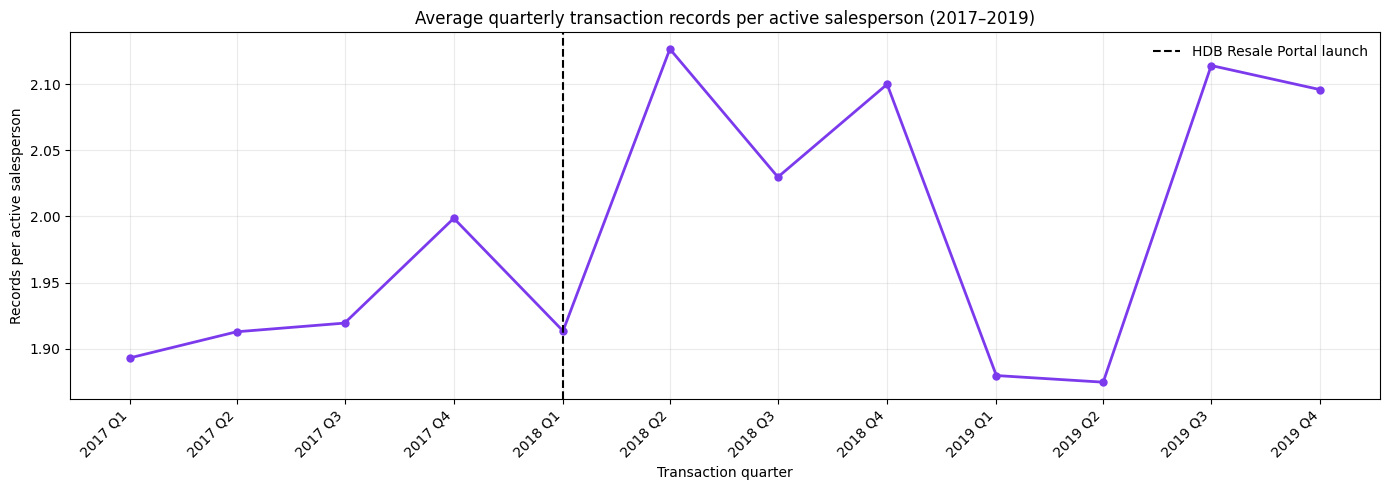

,transaction_quarter,transaction_records,active_salespersons,transactions_per_active_salesperson
0,2017-01-01,7360,3888,1.893004
1,2017-04-01,7435,3887,1.912786
2,2017-07-01,7593,3956,1.919363
3,2017-10-01,8776,4391,1.998634
4,2018-01-01,8000,4181,1.913418
5,2018-04-01,9836,4625,2.126703
6,2018-07-01,8986,4427,2.029817
7,2018-10-01,8860,4219,2.100024
8,2019-01-01,6609,3516,1.879693
9,2019-04-01,6387,3407,1.874670


,period,mean_quarterly_transactions_per_active_salesperson,change_vs_2017_pct
0,2017 pre-launch,1.93,0.00
1,2018–2019 post-launch,2.02,4.45


In [8]:
# METRIC DEFINITION
# Average quarterly transactions per salesperson = quarterly transaction records / unique active registration numbers.
# The denominator contains salespersons who were active at least once during that quarter.
# The chart ends in December 2019 because COVID-19 began in December 2019.
# Aggregating by quarter reduces monthly volatility while retaining the pre- and post-launch pattern.

# Create a quarter-start date from each transaction month for quarterly grouping and plotting.
quarterly_salesperson_eda = salesperson_eda.copy()
quarterly_salesperson_eda["transaction_quarter"] = quarterly_salesperson_eda["transaction_month"].dt.to_period("Q").dt.start_time

# Compute total records and the unique active salesperson denominator for each quarter.
quarterly_agent_metrics = (
    quarterly_salesperson_eda.groupby("transaction_quarter", as_index=False)
    .agg(
        transaction_records=("salesperson_reg_num", "size"),
        active_salespersons=("salesperson_reg_num", "nunique")
    )
)

# Calculate the average number of records handled per active salesperson each quarter.
quarterly_agent_metrics["transactions_per_active_salesperson"] = (
    quarterly_agent_metrics["transaction_records"] / quarterly_agent_metrics["active_salespersons"]
)

quarterly_agent_metric_2017_2019 = quarterly_agent_metrics[
    quarterly_agent_metrics["transaction_quarter"].between("2017-01-01", "2019-12-31")
].copy()

fig, ax = plt.subplots(figsize=(14, 5))
# Plot the quarterly average transactions per active salesperson metric.
ax.plot(quarterly_agent_metric_2017_2019["transaction_quarter"],
        quarterly_agent_metric_2017_2019["transactions_per_active_salesperson"],
        color="#7c3aed", marker="o", markersize=5, linewidth=2)
# Draw a vertical line at the HDB Resale Portal launch date.
ax.axvline(pd.Timestamp("2018-01-01"), color="black", linestyle="--", linewidth=1.5,
           label="HDB Resale Portal launch")
ax.set(title="Average quarterly transaction records per active salesperson (2017–2019)",
       xlabel="Transaction quarter", ylabel="Records per active salesperson")

# Formatting
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y Q%q"))
ax.set_xticks(quarterly_agent_metric_2017_2019["transaction_quarter"])
ax.set_xticklabels([
    f"{date.year} Q{date.quarter}" for date in quarterly_agent_metric_2017_2019["transaction_quarter"]
], rotation=45, ha="right")
ax.grid(alpha=0.25)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

pre_quarterly_agent = quarterly_agent_metric_2017_2019[
    quarterly_agent_metric_2017_2019["transaction_quarter"].dt.year == 2017
]
post_quarterly_agent = quarterly_agent_metric_2017_2019[
    quarterly_agent_metric_2017_2019["transaction_quarter"].dt.year.isin([2018, 2019])
]

# Build a summary table comparing pre- and post-launch quarterly productivity.
quarterly_agent_productivity_comparison = pd.DataFrame({
    "period": ["2017 pre-launch", "2018–2019 post-launch"],
    # Store the mean quarterly productivity for each period.
    "mean_quarterly_transactions_per_active_salesperson": [
        pre_quarterly_agent["transactions_per_active_salesperson"].mean(),
        post_quarterly_agent["transactions_per_active_salesperson"].mean()
    ]
})

# Compute the percentage change versus the 2017 quarterly baseline.
quarterly_agent_productivity_comparison["change_vs_2017_pct"] = (
    quarterly_agent_productivity_comparison["mean_quarterly_transactions_per_active_salesperson"]
    / quarterly_agent_productivity_comparison.loc[0, "mean_quarterly_transactions_per_active_salesperson"] - 1
) * 100

# Display the quarterly metrics and rounded pre/post comparison for verification.
display(quarterly_agent_metric_2017_2019)
display(quarterly_agent_productivity_comparison.round(2))

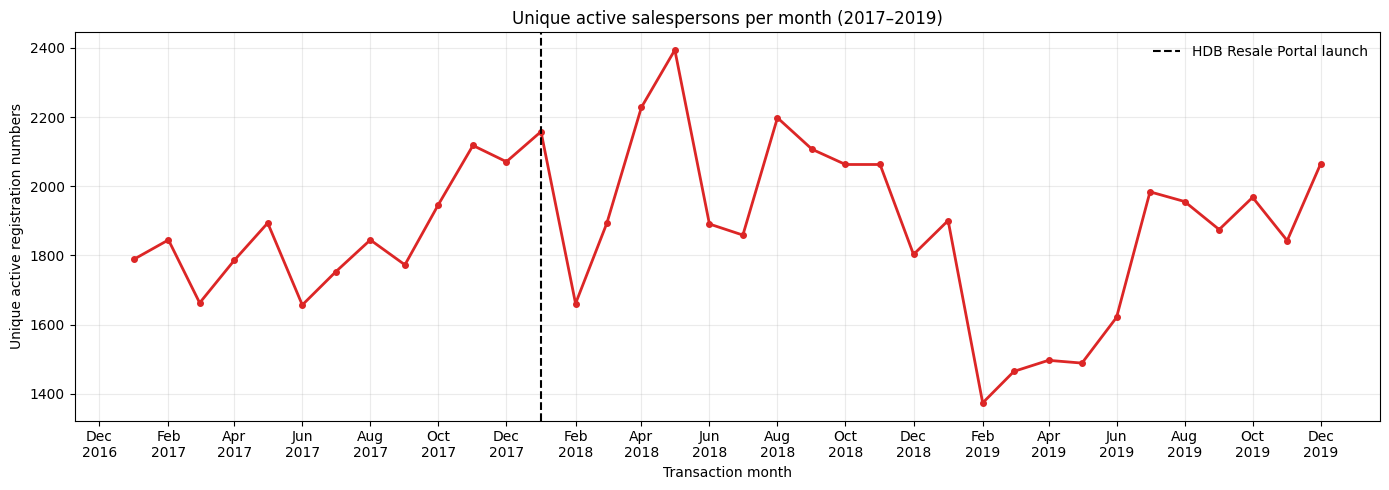

,period,mean_monthly_active_salespersons,change_vs_2017_pct
0,2017 pre-launch,1845.08,0.00
1,2018–2019 post-launch,1889.83,2.43


In [9]:
# QUESTION: How many unique salesperson registration numbers transact each month?

active_2017_2019 = monthly_agent_metrics[
    monthly_agent_metrics["transaction_month"].between("2017-01-01", "2019-12-31")
].copy()

fig, ax = plt.subplots(figsize=(14, 5))
# Plot the monthly count of unique active salespersons.
ax.plot(active_2017_2019["transaction_month"], active_2017_2019["active_salespersons"],
        color="#dc2626", marker="o", markersize=4, linewidth=2)
ax.axvline(pd.Timestamp("2018-01-01"), color="black", linestyle="--", linewidth=1.5,
           label="HDB Resale Portal launch")
ax.set(title="Unique active salespersons per month (2017–2019)",
       xlabel="Transaction month", ylabel="Unique active registration numbers")

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.grid(alpha=0.25)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

pre_active = active_2017_2019[active_2017_2019["transaction_month"].dt.year == 2017]
post_active = active_2017_2019[active_2017_2019["transaction_month"].dt.year.isin([2018, 2019])]
# Build a summary table comparing active salesperson levels before and after launch.
active_agent_comparison = pd.DataFrame({
    "period": ["2017 pre-launch", "2018–2019 post-launch"],
    "mean_monthly_active_salespersons": [
        pre_active["active_salespersons"].mean(),
        post_active["active_salespersons"].mean()
    ]
})
# Compute the percentage change versus the 2017 baseline.
active_agent_comparison["change_vs_2017_pct"] = (
    active_agent_comparison["mean_monthly_active_salespersons"]
    / active_agent_comparison.loc[0, "mean_monthly_active_salespersons"] - 1
) * 100
display(active_agent_comparison.round(2))

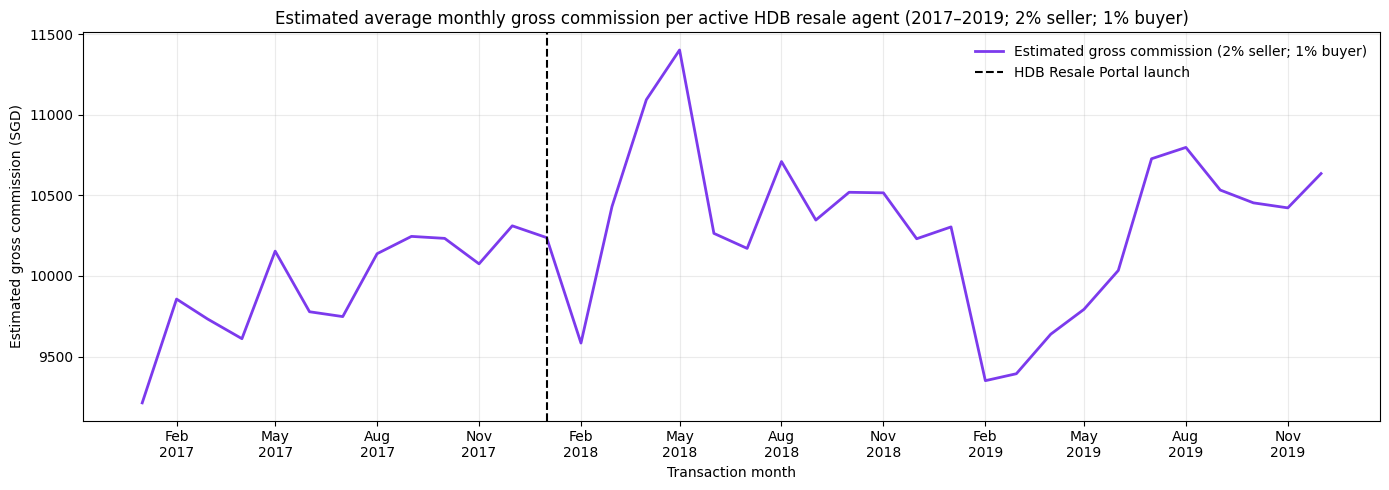

Exact town-month match rate: 100.00%
Final price match rate after three-month fallback: 100.00%


,price_match_source,agent_record_count
0,exact_month,97297


,transaction_month,town,average_resale_price,hdb_resale_transactions
0,2017-01-01,ANG MO KIO,413971.214286,56
1,2017-01-01,BEDOK,408598.400000,70
2,2017-01-01,BISHAN,604892.181818,22
3,2017-01-01,BUKIT BATOK,373450.808511,47
4,2017-01-01,BUKIT MERAH,512267.857143,56


,transaction_month,active_hdb_resale_agents,total_agent_side_hdb_records,average_hdb_records_per_agent,average_associated_value_per_agent,average_estimated_gross_commission,average_imputed_value_per_record
0,2017-01-01,1789,2453,1.371157,586185.993210,9212.497835,427511.920853
1,2017-02-01,1845,2596,1.407046,622589.151327,9856.413637,442479.577888
2,2017-03-01,1662,2310,1.389892,608899.059743,9732.837387,438091.011815
3,2017-04-01,1786,2468,1.381859,602142.416269,9610.673758,435748.118094
4,2017-05-01,1894,2713,1.432418,635360.918805,10153.782892,443558.267681


In [10]:
# HDB PRICE PREPARATION
# Average resale price is calculated by transaction month and town
# We retain transaction counts to understand the support behind each town-month average.

hdb_eda = resale_prices_df.copy()
hdb_eda["transaction_month"] = pd.to_datetime(hdb_eda["month"], format="%Y-%m", errors="coerce")
hdb_eda = hdb_eda.loc[
    hdb_eda["transaction_month"].between("2017-01-01", "2019-12-31")
].copy()
# Standardize town names for consistent joins.
hdb_eda["town"] = hdb_eda["town"].astype("string").str.strip().str.upper()

hdb_eda["resale_price"] = pd.to_numeric(hdb_eda["resale_price"], errors="coerce")
hdb_eda = hdb_eda.dropna(subset=["transaction_month", "town", "resale_price"])

# Compute the average price and supporting transaction count for each town-month.
hdb_town_month_prices = (
    hdb_eda.groupby(["transaction_month", "town"], as_index=False)
    .agg(
        average_resale_price=("resale_price", "mean"),
        hdb_resale_transactions=("resale_price", "size")
    )
)

# JOIN AND EARNINGS PROXY
# The records do not contain actual sale prices, commission rates, commission splits, or agency fees.
# Therefore:
#   1) 'associated_transaction_value' is a market-value proxy, not revenue.
#   2) EdgeProp states that seller-paid commission is typically 2% and buyer-paid commission is typically 1%:
#      https://buddy.edgeprop.sg/discover/what-is-the-average-property-agent-commission-in-singapore-1bc9eace-ea29-42e2-9119-b7bbcac8c68c
#      Those rates are applied to SELLER and BUYER agent-side records respectively

# Keep only HDB resale agent-side records through December 2019.
agent_hdb_resale = salesperson_eda[
    (salesperson_eda["property_type"] == "HDB")
    & (salesperson_eda["transaction_type"] == "RESALE")
    & (salesperson_eda["transaction_month"] <= "2019-12-31")
    # Exclude town values that cannot be joined.
    # Validation has been done to ensure that this null town HDB resales are not significant in size 
    & (salesperson_eda["town"] != "-")
].copy()

agent_hdb_resale["agent_record_id"] = np.arange(len(agent_hdb_resale))

# Join the exact transaction-month and town price first because it is the most precise available match.
agent_hdb_valued = agent_hdb_resale.merge(
    hdb_town_month_prices,
    on=["transaction_month", "town"],
    how="left",
    # hdb_town_month_prices keys are unique
    validate="many_to_one"
)

# Identify rows that received an exact town-month average resale price.
agent_hdb_valued["price_match_source"] = np.where(
    agent_hdb_valued["average_resale_price"].notna(),
    "exact_month",
    pd.NA
)

exact_match_rate = agent_hdb_valued["average_resale_price"].notna().mean()
# Next is fallback handling if no town-month price can be found
# Fallback to the same town average price for the next 3 months

# Select only records whose exact town-month price remains null for the three-month fallback.
missing_after_exact = agent_hdb_valued.loc[
    agent_hdb_valued["average_resale_price"].isna(),
    ["agent_record_id", "transaction_month", "town"]
].copy()

future_price_lookup = hdb_town_month_prices[["transaction_month", "town", "average_resale_price"]].rename(
    columns={"transaction_month": "price_month", "average_resale_price": "future_average_resale_price"}
)

# Pair each exact-match failure with price observations from the same town.
three_month_candidates = missing_after_exact.merge(
    # Attach all same-town price observations before limiting the time window.
    future_price_lookup,
    on="town",
    how="left"
)

# Keep only prices occurring in the one to three months after the agent transaction month.
three_month_candidates = three_month_candidates.loc[
    (three_month_candidates["price_month"] > three_month_candidates["transaction_month"])
    & (three_month_candidates["price_month"] <= three_month_candidates["transaction_month"] + pd.DateOffset(months=3))
].copy()

# Calculate the same-town mean price available during the next three months for each unmatched record.
three_month_prices = three_month_candidates.groupby("agent_record_id", as_index=False).agg(
    three_month_mean_price=("future_average_resale_price", "mean")
)
# Attach the three-month fallback mean to every agent-side record.
agent_hdb_valued = agent_hdb_valued.merge(
    three_month_prices,
    on="agent_record_id",
    how="left",
    validate="one_to_one"
)

# Replace only still-null exact prices with their available next-three-month town mean.
agent_hdb_valued["average_resale_price"] = agent_hdb_valued["average_resale_price"].fillna(
    agent_hdb_valued["three_month_mean_price"]
)
# Label records whose null exact prices were filled by the next-three-month town mean.
agent_hdb_valued.loc[
    agent_hdb_valued["price_match_source"].isna() & agent_hdb_valued["three_month_mean_price"].notna(),
    "price_match_source"
] = "next_3_month_mean"
agent_hdb_valued["price_match_source"] = agent_hdb_valued["price_match_source"].fillna("unmatched")
# Calculate final price coverage after the exact and three-month fill steps.
join_match_rate = agent_hdb_valued["average_resale_price"].notna().mean()
# Summarize record counts by the price source used for auditability.
price_match_summary = agent_hdb_valued["price_match_source"].value_counts(dropna=False).rename_axis("price_match_source").reset_index(name="agent_record_count")

# Use the matched town-month average resale price as the attributed transaction value proxy.
agent_hdb_valued["associated_transaction_value"] = agent_hdb_valued["average_resale_price"]
# Apply a 2% estimated commission rate to seller-represented records and a 1% rate to buyer-represented records
agent_hdb_valued["estimated_commission_rate"] = agent_hdb_valued["represented"].map({"SELLER": 0.02, "BUYER": 0.01})
# Verify that every HDB resale record received a role-specific commission rate.
assert agent_hdb_valued["estimated_commission_rate"].notna().all(), "Missing buyer or seller commission-rate mapping"

agent_hdb_valued["estimated_gross_commission"] = (
    agent_hdb_valued["associated_transaction_value"] * agent_hdb_valued["estimated_commission_rate"]
)

# Sum each active salesperson's attributed records in a month, then average across active HDB resale agents.
agent_month_hdb_value = (
    agent_hdb_valued.groupby(["transaction_month", "salesperson_reg_num"], as_index=False)
    .agg(
        # Count how many HDB resale records are attributed to the salesperson that month.
        hdb_resale_records=("salesperson_reg_num", "size"),
        # Sum the associated transaction value across the salesperson's records.
        associated_transaction_value=("associated_transaction_value", "sum"),
        # Sum estimated role-specific gross commission across the salesperson's records.
        estimated_gross_commission=("estimated_gross_commission", "sum")
    )
)

# Aggregate the salesperson-month metrics into monthly averages across active HDB resale agents.
monthly_hdb_agent_value = (
    agent_month_hdb_value.groupby("transaction_month", as_index=False)
    .agg(
        # Count active HDB resale salespersons in the month.
        active_hdb_resale_agents=("salesperson_reg_num", "nunique"),
        # Sum total agent-side HDB resale records in the month.
        total_agent_side_hdb_records=("hdb_resale_records", "sum"),
        # Average HDB resale records per active salesperson in the month.
        average_hdb_records_per_agent=("hdb_resale_records", "mean"),
        # Average attributed transaction value per active salesperson in the month.
        average_associated_value_per_agent=("associated_transaction_value", "mean"),
        # Average role-specific estimated gross commission per active salesperson in the month.
        average_estimated_gross_commission=("estimated_gross_commission", "mean")
    )
)

# Divide the average associated value per agent by the average HDB records per agent.
monthly_hdb_agent_value["average_imputed_value_per_record"] = (
    monthly_hdb_agent_value["average_associated_value_per_agent"]
    / monthly_hdb_agent_value["average_hdb_records_per_agent"]
)

# Plot the monthly average role-weighted estimated gross commission per active HDB resale agent.
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_hdb_agent_value["transaction_month"],
        monthly_hdb_agent_value["average_estimated_gross_commission"],
        color="#7c3aed", linewidth=2, label="Estimated gross commission (2% seller; 1% buyer)")
ax.axvline(pd.Timestamp("2018-01-01"), color="black", linestyle="--", linewidth=1.5,
           label="HDB Resale Portal launch")
ax.set(title="Estimated average monthly gross commission per active HDB resale agent (2017–2019; 2% seller; 1% buyer)",
       xlabel="Transaction month", ylabel="Estimated gross commission (SGD)")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.grid(alpha=0.25)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

# Print exact and final price-match coverage so the three-month null-replacement step can be checked.
print(f"Exact town-month match rate: {exact_match_rate:.2%}")
print(f"Final price match rate after three-month fallback: {join_match_rate:.2%}")
display(price_match_summary)
display(hdb_town_month_prices.head())
display(monthly_hdb_agent_value.head())

In [11]:
# QUANTIFIED BUSINESS IMPACT
# Use August–December 2017 as the five-month pre-launch baseline because the upward trend begins in July.
impact_window = monthly_hdb_agent_value[
    monthly_hdb_agent_value["transaction_month"].between("2017-01-01", "2019-12-31")
    & (monthly_hdb_agent_value["transaction_month"] != "2018-01-01")
].copy()

impact_window["period"] = np.select(
    [
        impact_window["transaction_month"].between("2017-08-01", "2017-12-01"),
        impact_window["transaction_month"].between("2018-01-01", "2018-02-01"),
        impact_window["transaction_month"].between("2018-03-01", "2018-06-01"),
        impact_window["transaction_month"].between("2018-07-01", "2019-12-31")
    ],
    [
        "August–December 2017: pre launch",
        "January–February 2018: right after launch",
        "March–June 2018: 2–5 months after launch",
        "After June 2018: long-term impact"
    ],
    default=pd.NA
)

# Aggregate the key HDB agent metrics by launch-timing period.
hdb_impact = (
    impact_window.groupby("period", as_index=False)
    .agg(
        # Average the monthly count of active HDB resale agents.
        mean_monthly_active_hdb_resale_agents=("active_hdb_resale_agents", "mean"),
        # Average the monthly HDB records per active agent.
        mean_monthly_hdb_records_per_agent=("average_hdb_records_per_agent", "mean"),
        # Average the imputed resale value per HDB agent-side record.
        mean_imputed_value_per_hdb_record=("average_imputed_value_per_record", "mean"),
        # Average the monthly associated transaction value per active agent.
        mean_monthly_associated_value_per_agent=("average_associated_value_per_agent", "mean"),
        # Average the role-weighted estimated gross commission per active agent.
        mean_monthly_estimated_gross_commission=("average_estimated_gross_commission", "mean")
    )
)

hdb_impact["period"] = pd.Categorical(
    hdb_impact["period"],
    categories=[
        "August–December 2017: pre launch",
        "January–February 2018: right after launch",
        "March–June 2018: 2–5 months after launch",
        "After June 2018: long-term impact"
    ],
    ordered=True
)
hdb_impact = hdb_impact.sort_values("period").reset_index(drop=True)
for col in [
    "mean_monthly_active_hdb_resale_agents",
    "mean_monthly_hdb_records_per_agent",
    "mean_imputed_value_per_hdb_record",
    "mean_monthly_associated_value_per_agent",
    "mean_monthly_estimated_gross_commission"
]:
    hdb_impact[f"{col}_change_vs_pre_launch_pct"] = (hdb_impact[col] / hdb_impact.loc[0, col] - 1) * 100

print("Descriptive comparison by launch-timing period")
display(hdb_impact.round(2))

# Build a concise summary of each period's percentage change versus the pre-launch baseline.
business_impact_summary = hdb_impact[[
    "period",
    "mean_monthly_hdb_records_per_agent_change_vs_pre_launch_pct",
    "mean_monthly_active_hdb_resale_agents_change_vs_pre_launch_pct",
    "mean_imputed_value_per_hdb_record_change_vs_pre_launch_pct",
    "mean_monthly_estimated_gross_commission_change_vs_pre_launch_pct"
]].melt(id_vars="period", var_name="indicator", value_name="change_vs_pre_launch_pct")

business_impact_summary["indicator"] = business_impact_summary["indicator"].replace({
    "mean_monthly_hdb_records_per_agent_change_vs_pre_launch_pct": "HDB resale records per active HDB agent",
    "mean_monthly_active_hdb_resale_agents_change_vs_pre_launch_pct": "Active HDB resale salespersons",
    "mean_imputed_value_per_hdb_record_change_vs_pre_launch_pct": "Imputed HDB value per agent-side record",
    "mean_monthly_estimated_gross_commission_change_vs_pre_launch_pct": "Estimated gross commission per active HDB resale agent (2% seller; 1% buyer)"
})
display(business_impact_summary.round(2))

print("Interpretation guardrails:")
print("1) The analysis ends in December 2019 to avoid COVID-19 disruption; August–December 2017 is the five-month pre-launch baseline.")
print("2) Estimated gross commission applies 2% to seller records and 1% to buyer records based on online sources; it excludes agency splits and expenses.")
print("3) Seasonality and market conditions prevent causal attribution.")

Descriptive comparison by launch-timing period


,period,mean_monthly_active_hdb_resale_agents,mean_monthly_hdb_records_per_agent,mean_imputed_value_per_hdb_record,mean_monthly_associated_value_per_agent,mean_monthly_estimated_gross_commission,mean_monthly_active_hdb_resale_agents_change_vs_pre_launch_pct,mean_monthly_hdb_records_per_agent_change_vs_pre_launch_pct,mean_imputed_value_per_hdb_record_change_vs_pre_launch_pct,mean_monthly_associated_value_per_agent_change_vs_pre_launch_pct,mean_monthly_estimated_gross_commission_change_vs_pre_launch_pct
0,August–December 2017: pre launch,1950.80,1.43,443525.51,633439.47,10200.30,0.00,0.00,0.00,0.00,0.00
1,January–February 2018: right after launch,1661.00,1.34,440954.32,591213.29,9583.54,-14.86,-6.13,-0.58,-6.67,-6.05
2,March–June 2018: 2–5 months after launch,2101.25,1.48,444848.19,659877.41,10797.02,7.71,3.86,0.30,4.17,5.85
3,After June 2018: long-term impact,1836.61,1.45,430612.23,626091.94,10253.92,-5.85,1.80,-2.91,-1.16,0.53


,period,indicator,change_vs_pre_launch_pct
0,August–December 2017: pre launch,HDB resale records per active HDB agent,0.00
1,January–February 2018: right after launch,HDB resale records per active HDB agent,-6.13
2,March–June 2018: 2–5 months after launch,HDB resale records per active HDB agent,3.86
3,After June 2018: long-term impact,HDB resale records per active HDB agent,1.80
4,August–December 2017: pre launch,Active HDB resale salespersons,0.00
5,January–February 2018: right after launch,Active HDB resale salespersons,-14.86
6,March–June 2018: 2–5 months after launch,Active HDB resale salespersons,7.71
7,After June 2018: long-term impact,Active HDB resale salespersons,-5.85
8,August–December 2017: pre launch,Imputed HDB value per agent-side record,0.00
9,January–February 2018: right after launch,Imputed HDB value per agent-side record,-0.58


Interpretation guardrails:
1) The analysis ends in December 2019 to avoid COVID-19 disruption; August–December 2017 is the five-month pre-launch baseline.
2) Estimated gross commission applies 2% to seller records and 1% to buyer records based on online sources; it excludes agency splits and expenses.
3) Seasonality and market conditions prevent causal attribution.


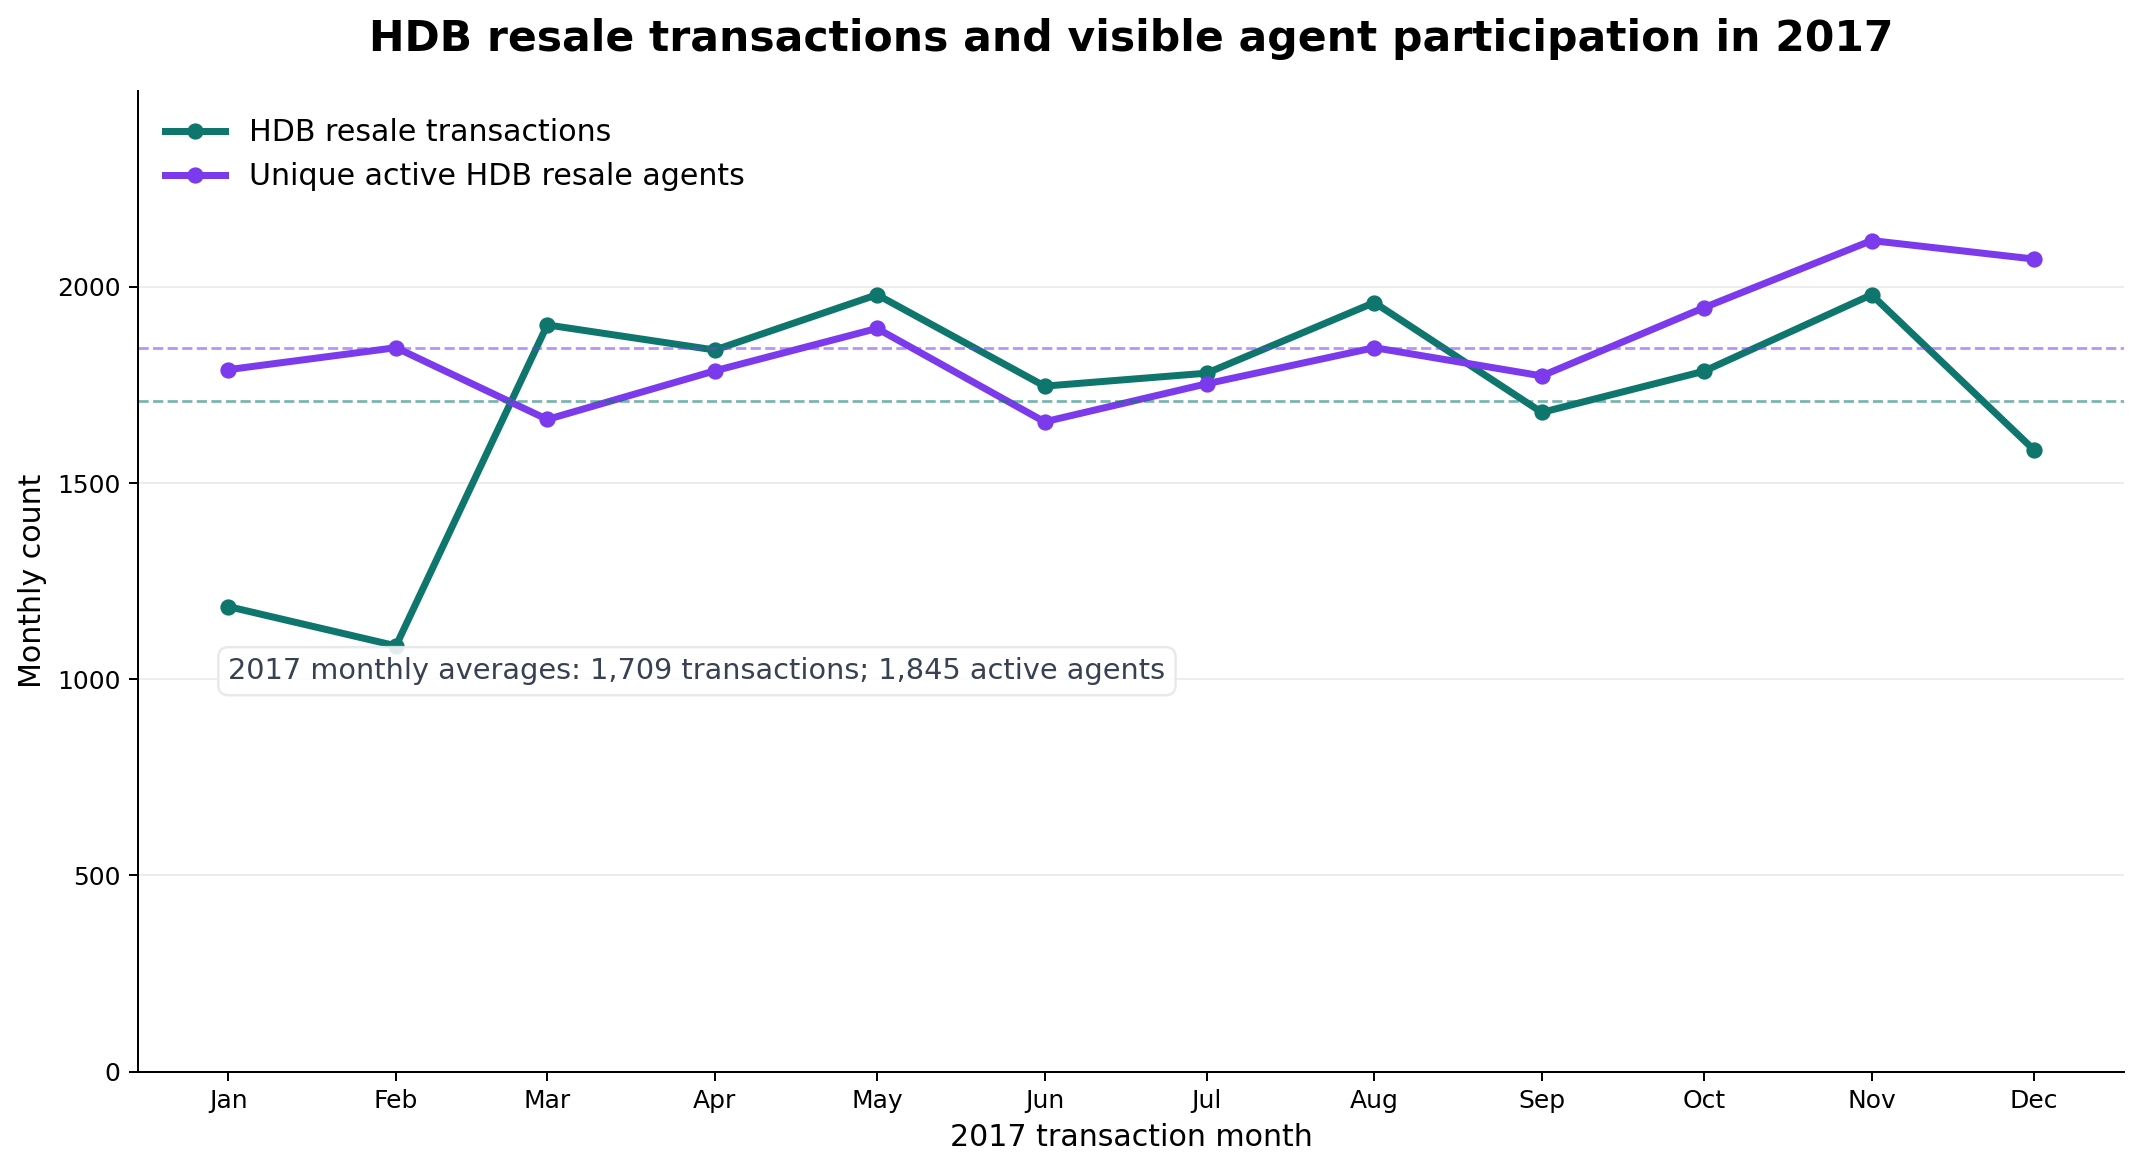

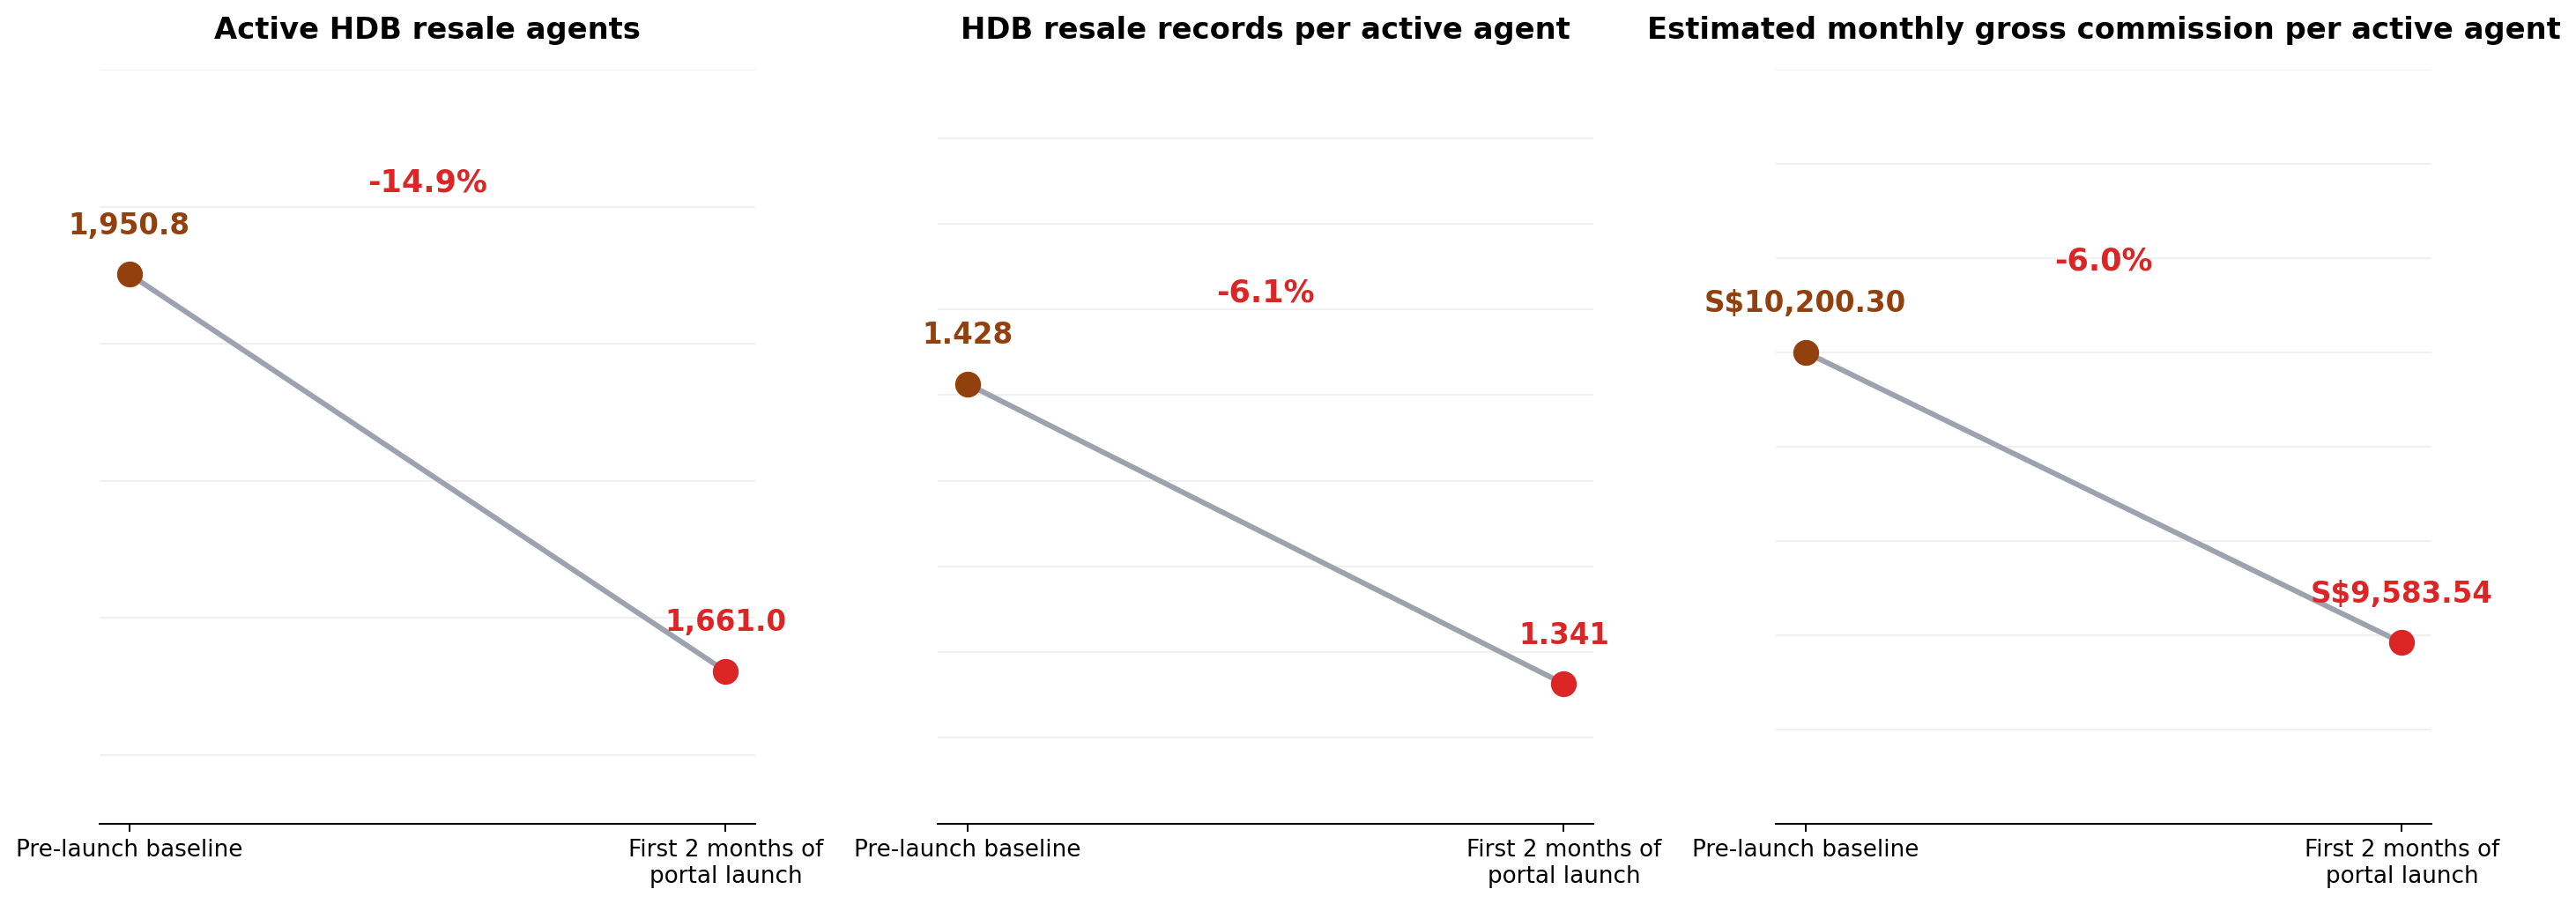

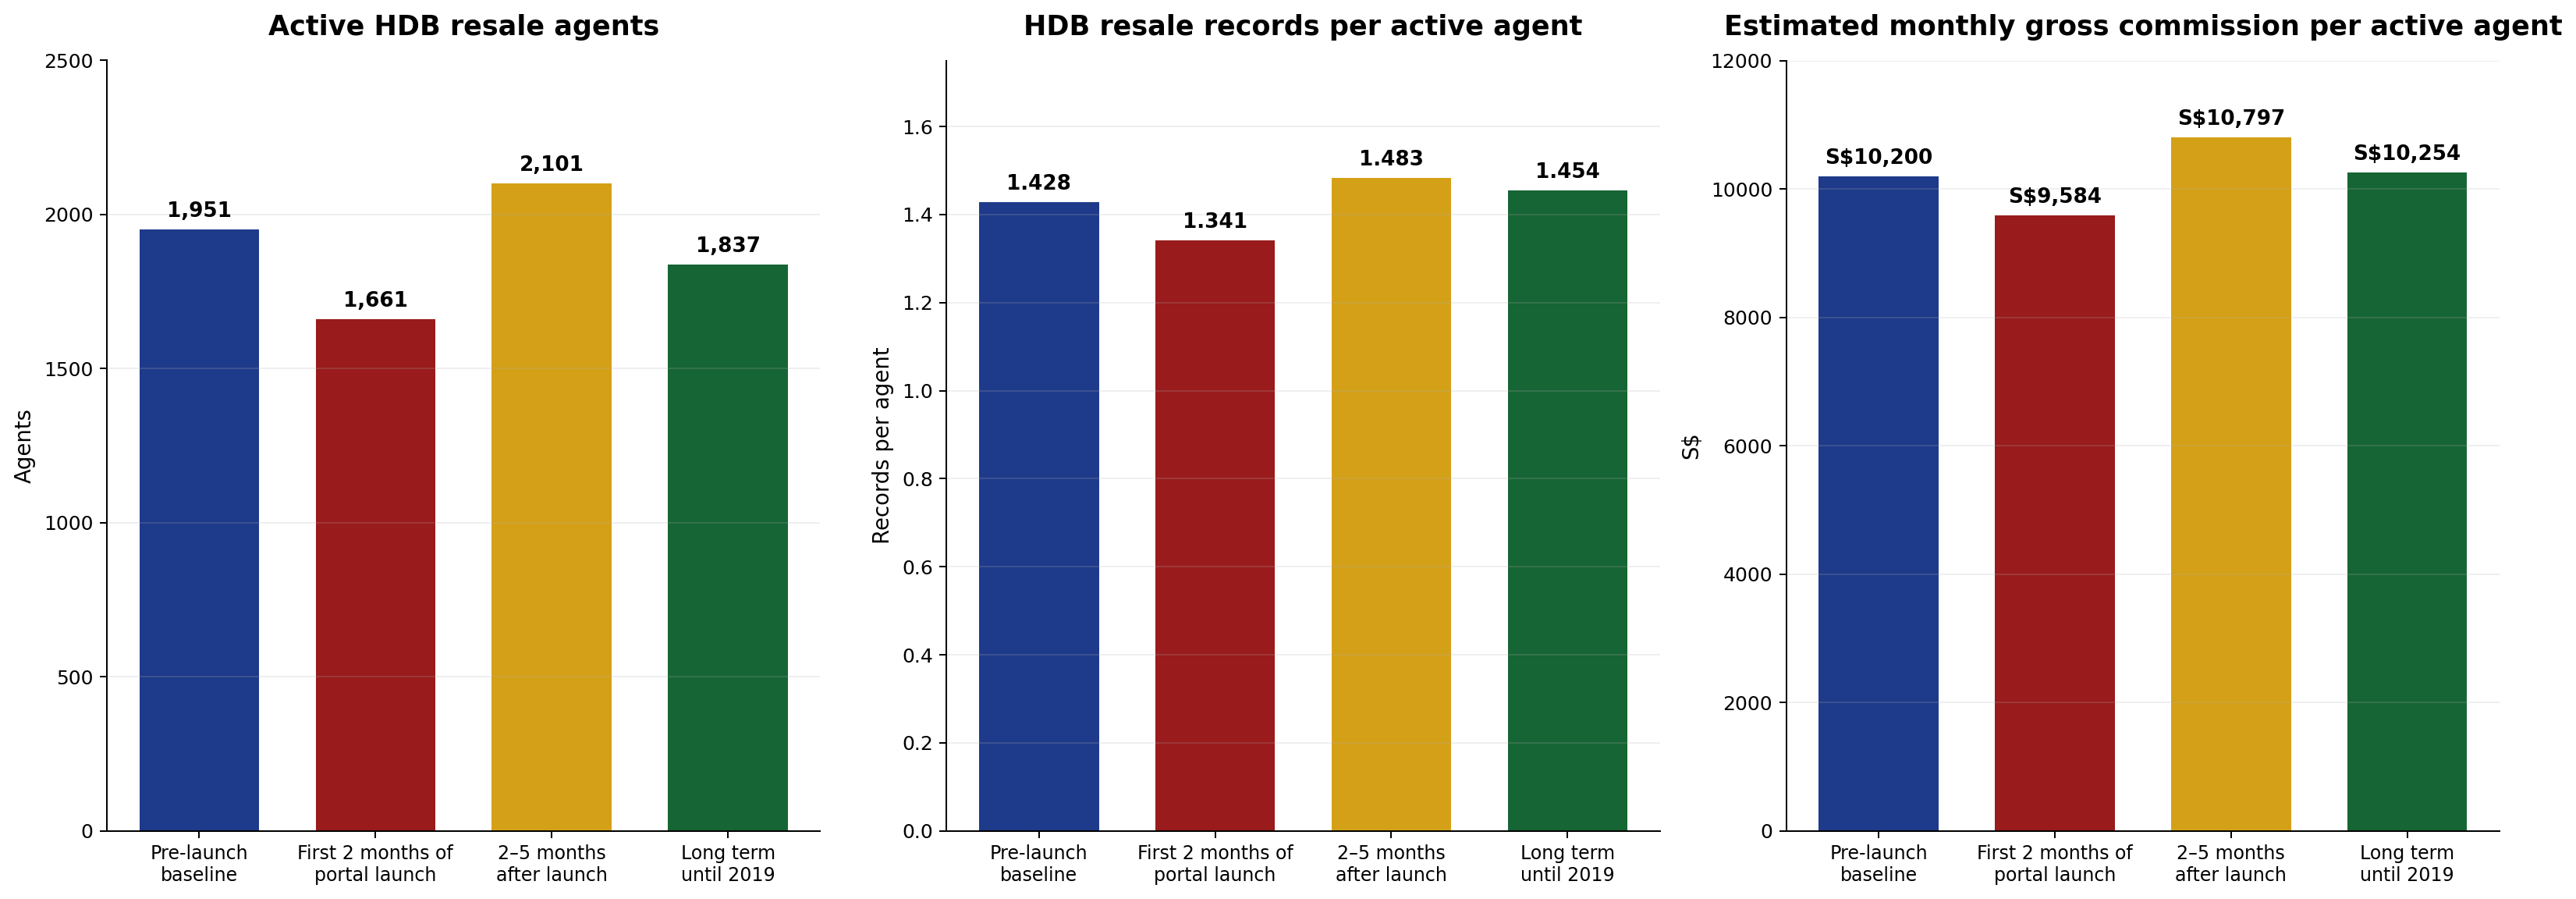

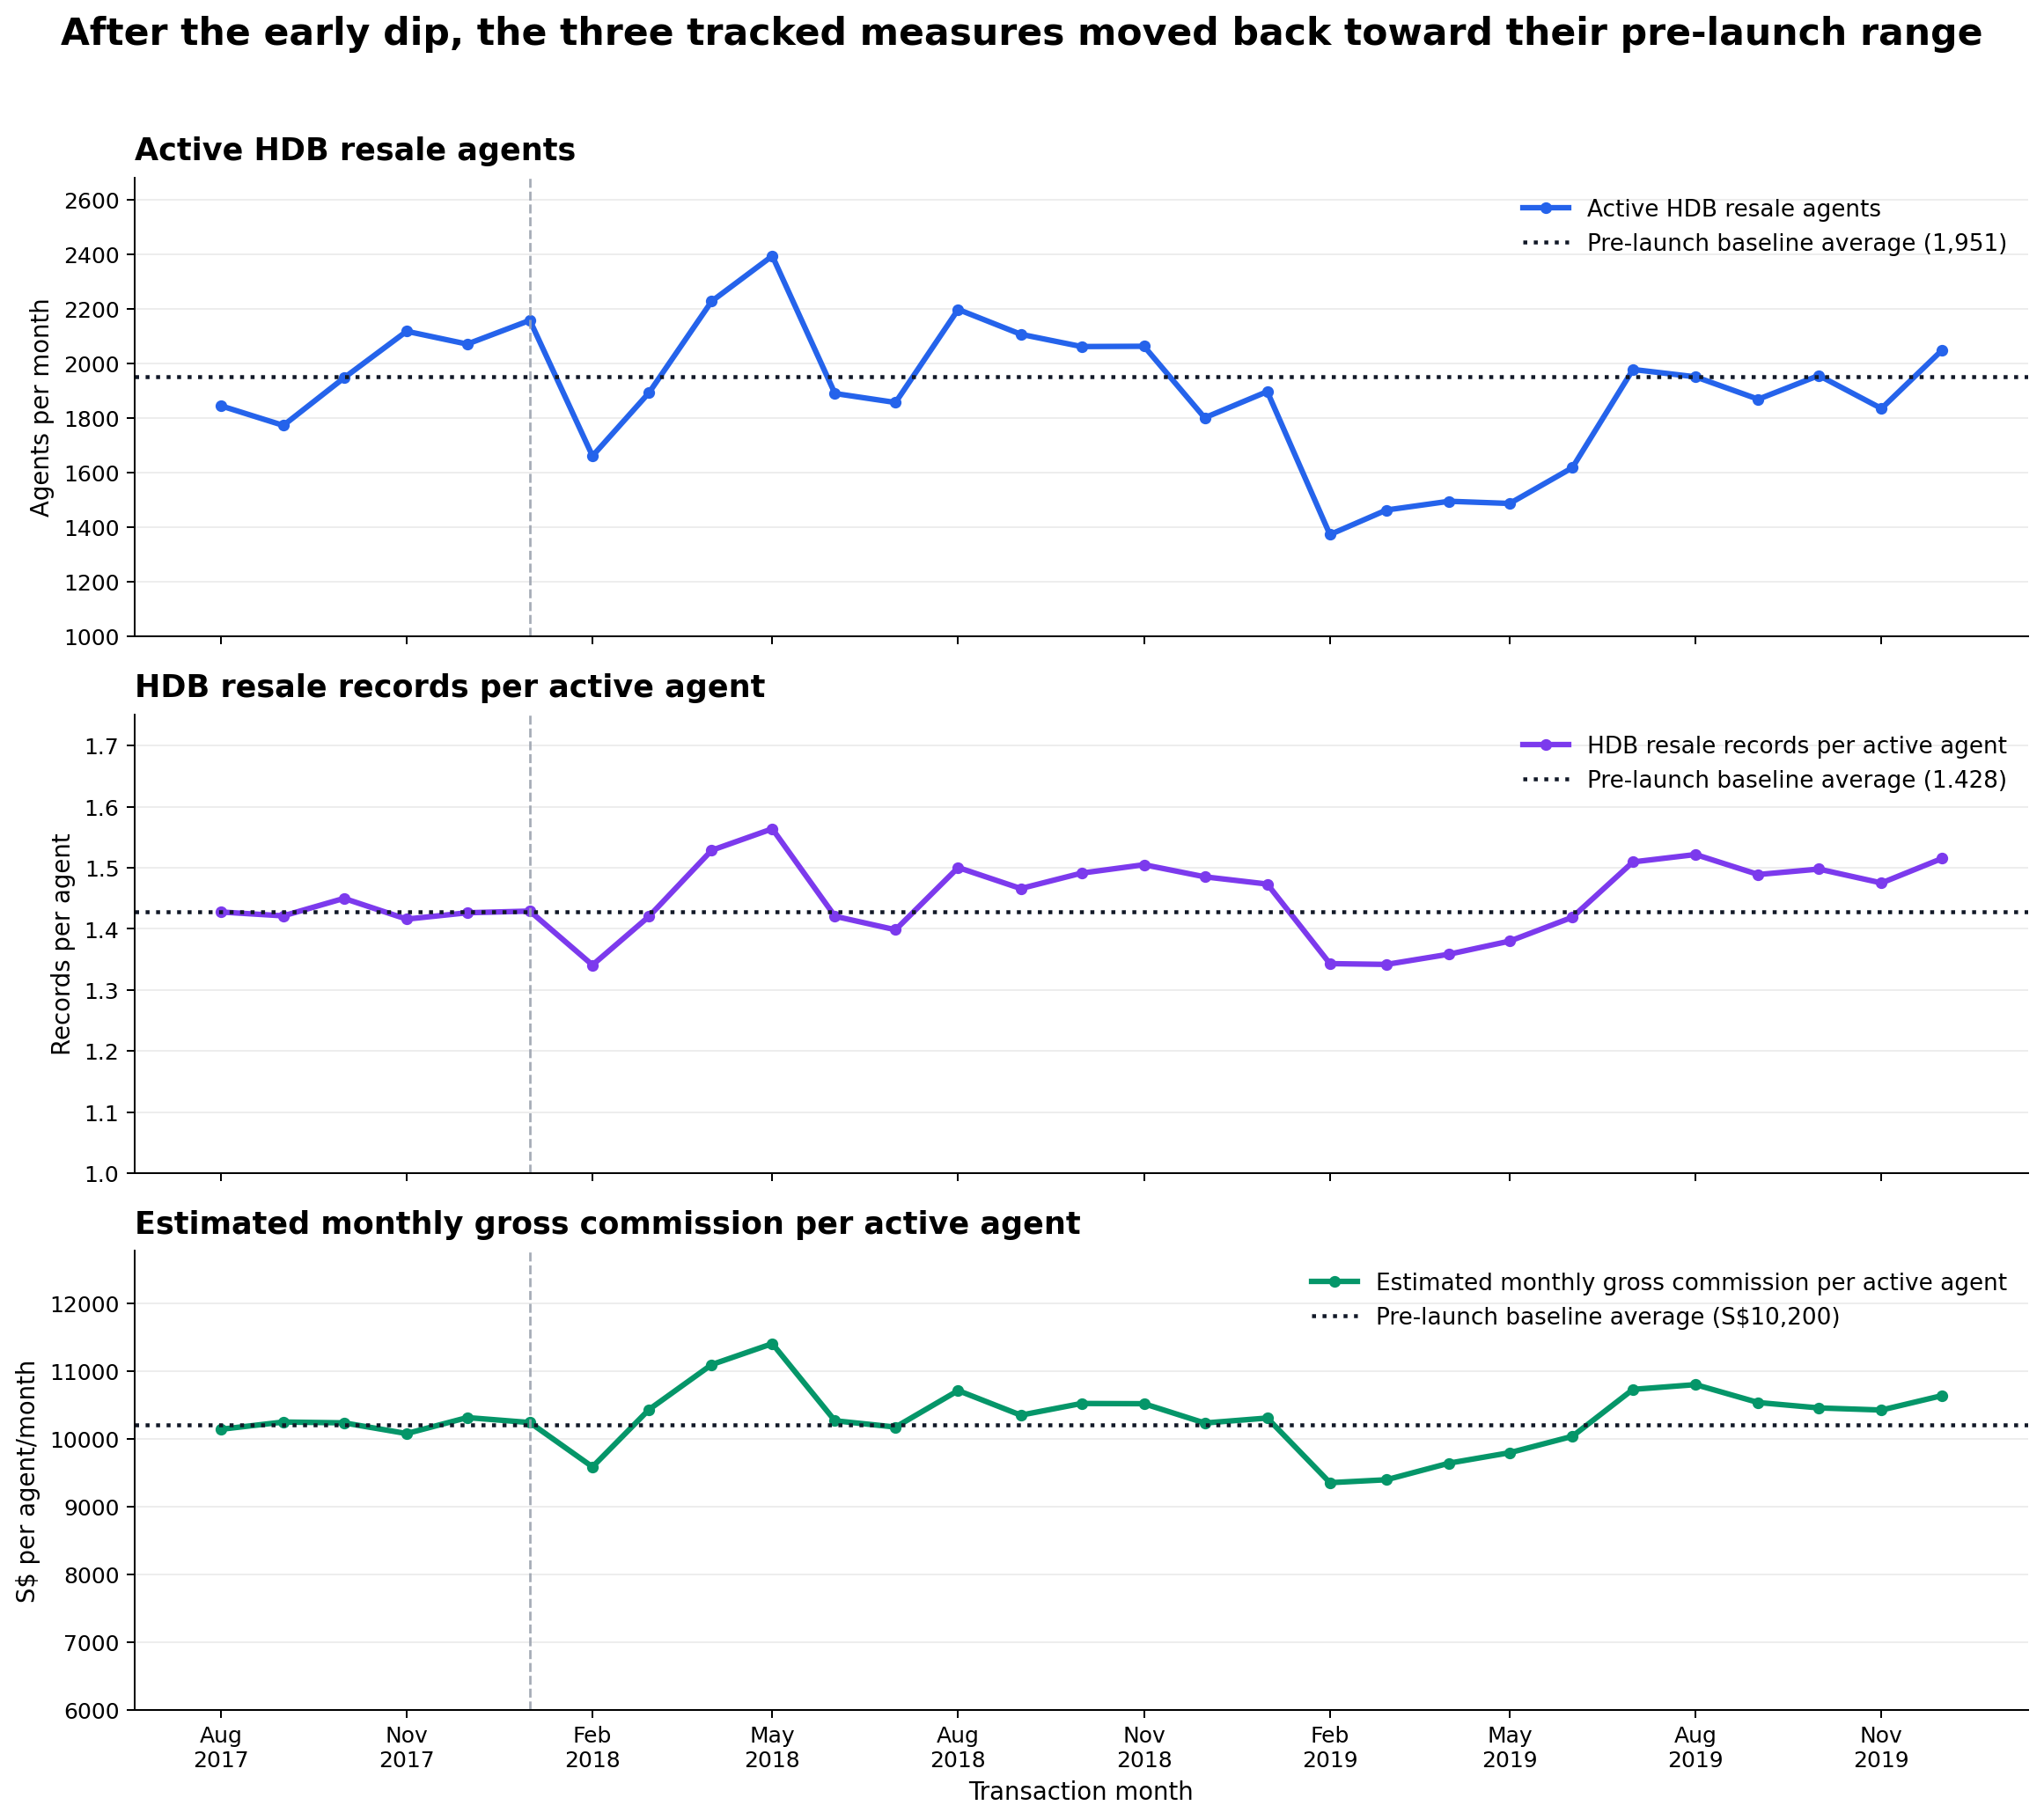

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

chart_2017 = hdb_market_role_monthly_2017.copy().sort_values("transaction_month")
avg_transactions = chart_2017["total_hdb_resale_transactions"].mean()
avg_agents = chart_2017["active_hdb_resale_agents"].mean()
fig, ax = plt.subplots(figsize=(12, 6.6), dpi=180)
ax.plot(chart_2017["transaction_month"], chart_2017["total_hdb_resale_transactions"], marker="o", linewidth=2.8, markersize=5.5, color="#0f766e", label="HDB resale transactions")
ax.plot(chart_2017["transaction_month"], chart_2017["active_hdb_resale_agents"], marker="o", linewidth=2.8, markersize=5.5, color="#7c3aed", label="Unique active HDB resale agents")
ax.axhline(avg_transactions, color="#0f766e", linestyle="--", linewidth=1.1, alpha=0.55)
ax.axhline(avg_agents, color="#7c3aed", linestyle="--", linewidth=1.1, alpha=0.55)
ax.text(chart_2017["transaction_month"].min(), 1000, f"2017 monthly averages: {avg_transactions:,.0f} transactions; {avg_agents:,.0f} active agents", fontsize=11.5, color="#374151", bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": "#e5e7eb", "alpha": 0.88})
ax.set_title("HDB resale transactions and visible agent participation in 2017", fontsize=17, weight="bold", pad=16)
ax.set_ylabel("Monthly count", fontsize=12)
ax.set_xlabel("2017 transaction month", fontsize=12)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.grid(axis="y", alpha=0.22)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper left", frameon=False, fontsize=12)
ax.set_ylim(0, max(chart_2017["total_hdb_resale_transactions"].max(), chart_2017["active_hdb_resale_agents"].max()) * 1.18)
plt.tight_layout()
display(fig)
plt.close(fig)


impact_two = hdb_impact.iloc[:2].copy()
comparison_labels = ["Pre-launch baseline", "First 2 months of\nportal launch"]
comparison_specs = [
    ("mean_monthly_active_hdb_resale_agents", "mean_monthly_active_hdb_resale_agents_change_vs_pre_launch_pct", "Active HDB resale agents", lambda v: f"{v:,.1f}", (1550, 2100)),
    ("mean_monthly_hdb_records_per_agent", "mean_monthly_hdb_records_per_agent_change_vs_pre_launch_pct", "HDB resale records per active agent", lambda v: f"{v:.3f}", (1.30, 1.52)),
    ("mean_monthly_estimated_gross_commission", "mean_monthly_estimated_gross_commission_change_vs_pre_launch_pct", "Estimated monthly gross commission per active agent", lambda v: f"S${v:,.2f}", (9200, 10800)),
]
fig, axes = plt.subplots(1, 3, figsize=(16, 5.8), dpi=180)
for ax, (value_col, change_col, title, formatter, limits) in zip(axes, comparison_specs):
    values = impact_two[value_col].to_numpy(dtype=float)
    change = float(impact_two.iloc[1][change_col])
    ax.plot([0, 1], values, color="#9ca3af", linewidth=2.4, zorder=1)
    ax.scatter([0], [values[0]], s=115, color="#92400e", zorder=2)
    ax.scatter([1], [values[1]], s=115, color="#dc2626", zorder=2)
    vertical_offset = (limits[1] - limits[0]) * 0.045
    ax.text(0, values[0] + vertical_offset, formatter(values[0]), ha="center", va="bottom", fontsize=13, weight="bold", color="#92400e")
    ax.text(1, values[1] + vertical_offset, formatter(values[1]), ha="center", va="bottom", fontsize=13, weight="bold", color="#dc2626")
    ax.text(0.5, max(values) + vertical_offset * 2.25, f"{change:+.1f}%", ha="center", va="bottom", fontsize=14, weight="bold", color="#dc2626")
    ax.set_xticks([0, 1], comparison_labels)
    ax.set_ylim(*limits)
    ax.set_title(title, fontsize=13.5, weight="bold", pad=14)
    ax.grid(axis="y", alpha=0.18)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(axis="y", left=False, labelleft=False)
    ax.tick_params(axis="x", labelsize=10.5)
plt.tight_layout()
display(fig)
plt.close(fig)


period_labels = ["Pre-launch\nbaseline", "First 2 months of\nportal launch", "2–5 months\nafter launch", "Long term\nuntil 2019"]
period_colors = ["#1e3a8a", "#991b1b", "#d4a017", "#166534"]
period_specs = [
    ("mean_monthly_active_hdb_resale_agents", "Active HDB resale agents", "Agents", lambda v: f"{v:,.0f}", (0, 2500)),
    ("mean_monthly_hdb_records_per_agent", "HDB resale records per active agent", "Records per agent", lambda v: f"{v:.3f}", (0, 1.75)),
    ("mean_monthly_estimated_gross_commission", "Estimated monthly gross commission per active agent", "S$", lambda v: f"S${v:,.0f}", (0, 12000)),
]
fig, axes = plt.subplots(1, 3, figsize=(18, 6.5), dpi=180)
for ax, (value_col, title, ylabel, formatter, limits) in zip(axes, period_specs):
    values = hdb_impact[value_col].to_numpy(dtype=float)
    bars = ax.bar(range(4), values, color=period_colors, width=0.68)
    ax.set_xticks(range(4), period_labels)
    ax.set_ylim(*limits)
    ax.set_title(title, fontsize=14, weight="bold", pad=13)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.grid(axis="y", alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="x", labelsize=9.5)
    ax.bar_label(bars, labels=[formatter(v) for v in values], padding=4, fontsize=10.5, weight="bold")
plt.tight_layout()
display(fig)
plt.close(fig)


metric_monthly = monthly_hdb_agent_value.loc[monthly_hdb_agent_value["transaction_month"].between("2017-08-01", "2019-12-31")].copy().sort_values("transaction_month")
baseline_window = metric_monthly.loc[metric_monthly["transaction_month"].between("2017-08-01", "2017-12-31")]
metric_specs = [
    ("active_hdb_resale_agents", "Active HDB resale agents", "Agents per month", "#2563eb", 1000, lambda v: f"{v:,.0f}"),
    ("average_hdb_records_per_agent", "HDB resale records per active agent", "Records per agent", "#7c3aed", 1.0, lambda v: f"{v:.3f}"),
    ("average_estimated_gross_commission", "Estimated monthly gross commission per active agent", "S$ per agent/month", "#059669", 6000, lambda v: f"S${v:,.0f}"),
]
fig, axes = plt.subplots(3, 1, figsize=(13, 11.5), dpi=180, sharex=True)
for ax, (column, title, ylabel, color, lower_bound, formatter) in zip(axes, metric_specs):
    values = metric_monthly[column]
    baseline_average = baseline_window[column].mean()
    ax.plot(metric_monthly["transaction_month"], values, color=color, linewidth=2.5, marker="o", markersize=4.3, label=title)
    ax.axhline(baseline_average, color="#111827", linewidth=1.8, linestyle=":", label=f"Pre-launch baseline average ({formatter(baseline_average)})")
    ax.axvline(pd.Timestamp("2018-01-01"), color="#9ca3af", linestyle="--", linewidth=1.1, alpha=0.9)
    ax.set_ylim(lower_bound, max(float(values.max()), float(baseline_average)) * 1.12)
    ax.set_title(title, loc="left", fontsize=14, weight="bold", pad=8)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.grid(axis="y", alpha=0.22)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(loc="upper right", frameon=False, fontsize=10.5)
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
axes[-1].set_xlabel("Transaction month", fontsize=11)
fig.suptitle("After the early dip, the three tracked measures moved back toward their pre-launch range", fontsize=17, weight="bold", y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.975])
display(fig)
plt.close(fig)